# 01 - Orbit Usage

This notebook is the first notebook in the Nebula Space Toolkit learning path.

You will learn how to:
- create two-body and numerical orbits
- query state in multiple frames
- use multiple time input types
- inspect ephemeris coverage and precompute cached intervals
- set attitude laws and read quaternion output
- use convenience state accessors and construct from `SpacecraftState`


## How To Use This Notebook

1. Run each code cell from top to bottom.
2. Methods in `Orbit` accept scalar or vector times and return matching shapes.
3. Use `*_np` methods for raw NumPy outputs and non-`_np` methods for `astropy.units` quantities.
4. Frame strings such as `"gcrf"`, `"itrf"`, and `"native"` are supported.


In [1]:
# Ensure local package import when running from this examples/ folder.
import sys
from pathlib import Path
%matplotlib widget
_cwd = Path.cwd().resolve()
_repo_root = _cwd if (_cwd / "nstk").is_dir() else _cwd.parent
if (_repo_root / "nstk").is_dir() and str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))


In [2]:
from time import perf_counter

import numpy as np
import astropy.units as u
from astropy.time import Time

from nstk.propagation import Orbit
from nstk.time_utils import astropy_time_to_orekit_date

np.set_printoptions(precision=6, suppress=True)


## 1) Build A Two-Body Orbit

Use this when you want a fast analytical propagator for initial design and quick trade studies.


epoch: 2026-01-01T00:00:00.000
native frame: GCRF
initial coverage [s from epoch]: (0.0, 0.0)


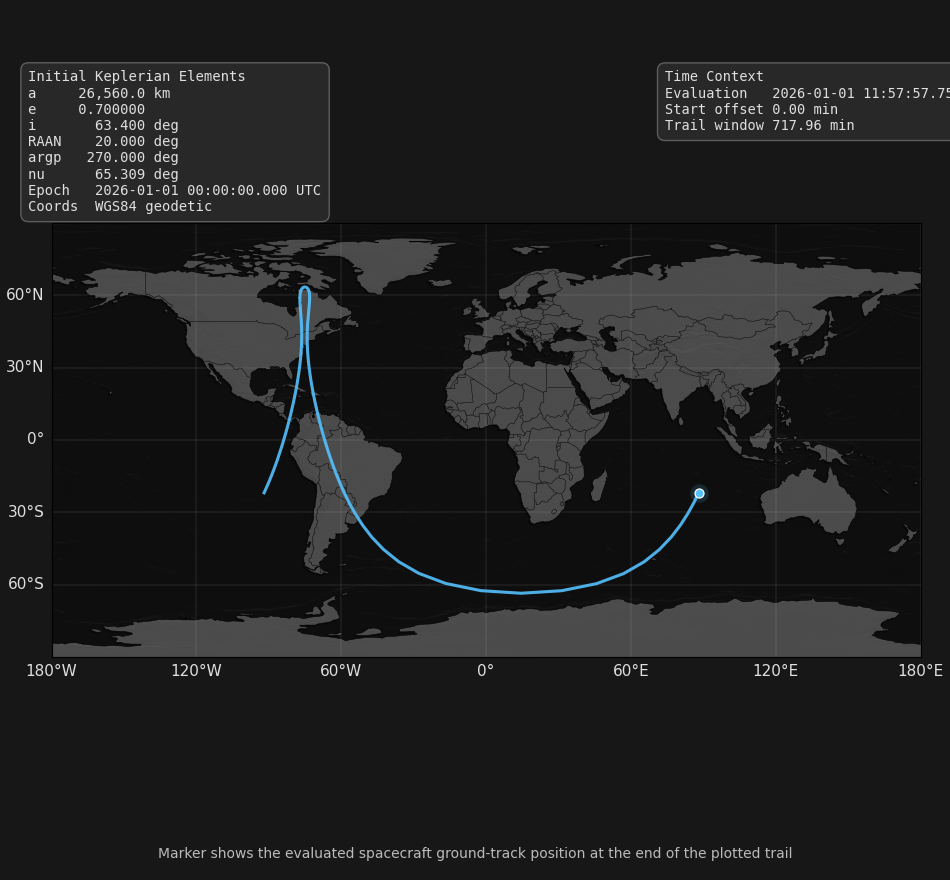

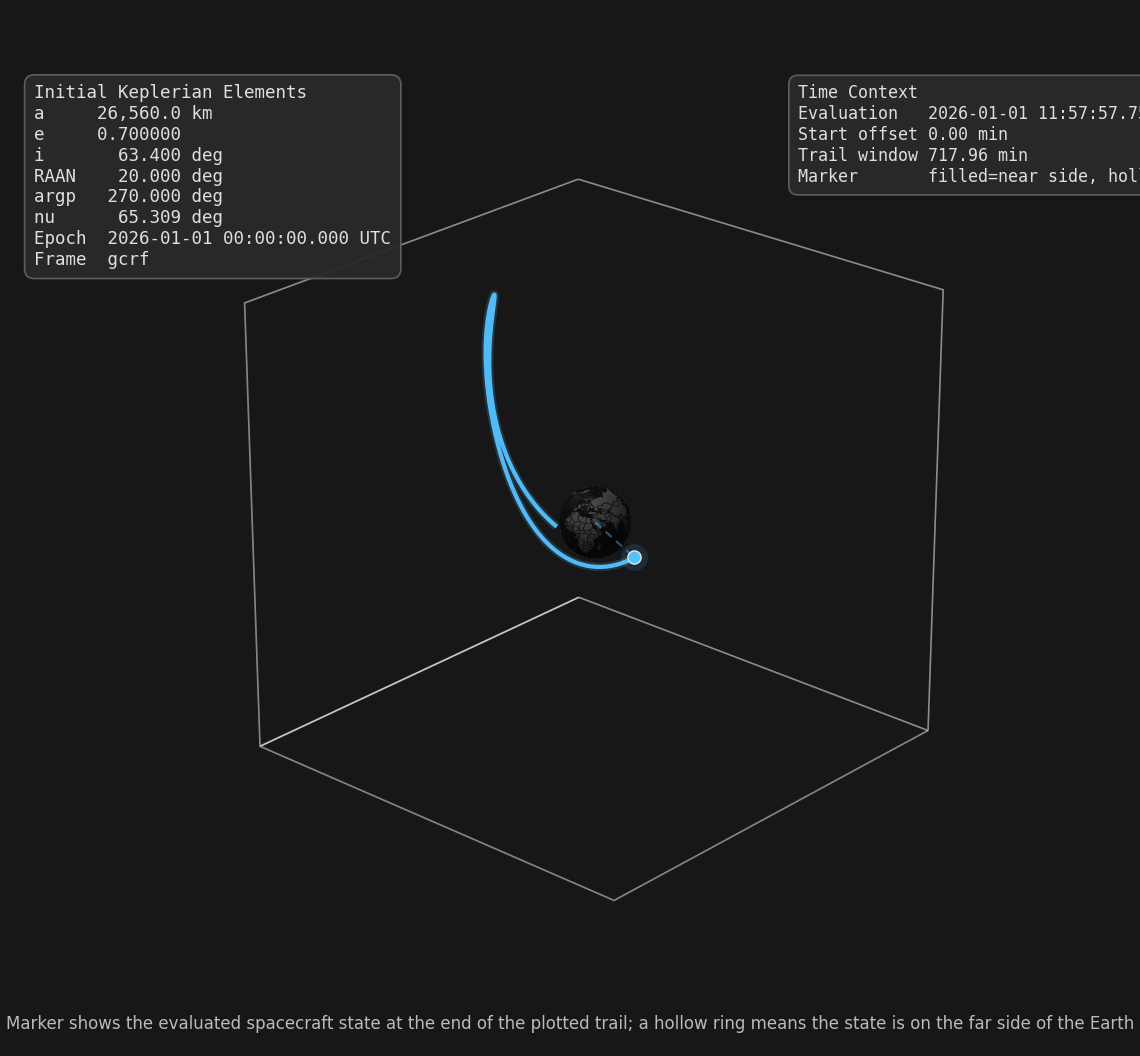

(<Figure size 1140x1056 with 1 Axes>, <Axes3D: >)

In [3]:
epoch = Time("2026-01-01T00:00:00", scale="utc")
orbit = Orbit.from_kepler_two_body(
    epoch=epoch,
    a=26560e3,
    e=0.7,
    i=np.deg2rad(63.4),
    raan=np.deg2rad(20.0),
    argp=np.deg2rad(270.0),
    anomaly=np.deg2rad(10.0),
    anomaly_type="mean",
)

print("epoch:", orbit.epoch.isot)
print("native frame:", orbit.get_native_frame().getName())
print("initial coverage [s from epoch]:", orbit.coverage())

# In the notebook, this figure is interactive when `%matplotlib widget` is active.
orbit.plot()
orbit.plot(view="3d")

## 2) Query Position, Velocity, Acceleration, And Geodetic Outputs

This shows frame switching (`gcrf`, `itrf`) and geodetic conversion (`lat`, `lon`, `alt`).


In [4]:
times = Time(epoch.unix + np.arange(0, 301, 60, dtype=np.float64), format="unix", scale="utc")
p_gcrf, v_gcrf, a_gcrf = orbit.get_pva(times, frame="gcrf")
p_itrf = orbit.get_p(times, frame="itrf")
lat, lon, alt = orbit.get_geodetic(times)

print("p_gcrf shape:", p_gcrf.shape)
print("v_gcrf shape:", v_gcrf.shape)
print("a_gcrf shape:", a_gcrf.shape)
print("p_itrf shape:", p_itrf.shape)
print("first geodetic sample [deg, deg, m]:", lat[0].value, lon[0].value, alt[0].value)


p_gcrf shape: (6, 3)
v_gcrf shape: (6, 3)
a_gcrf shape: (6, 3)
p_itrf shape: (6, 3)
first geodetic sample [deg, deg, m]: -21.868792691902854 -91.9681330524771 4105745.370044316


## 3) Scalar vs Vector Queries And `get_state`

- Scalar time input returns one vector (shape `(3,)`).
- Vector time input returns stacked vectors (shape `(N, 3)`).
- `get_state` can return one field (`p`, `v`, `a`) or grouped fields (`pv`, `pva`).


In [5]:
dt_s = np.array([0.0, 120.0, 240.0], dtype=np.float64)

r_scalar = orbit.get_p_np(0.0, frame="gcrf")
r_vector = orbit.get_p_np(dt_s, frame="gcrf")
v_vector_q = orbit.get_v(dt_s, frame="gcrf")

state_pv_np = orbit.get_state(dt_s, frame="gcrf", fields="pv", as_quantity=False)
state_a_q = orbit.get_state(180.0, frame="gcrf", fields="a", as_quantity=True)

print("scalar position shape:", r_scalar.shape)
print("vector position shape:", r_vector.shape)
print("velocity quantity unit:", v_vector_q.unit)
print("state_pv_np keys:", list(state_pv_np.keys()))
print("state_pv_np['p'] shape:", state_pv_np["p"].shape)
print("state_a_q['a']:", state_a_q["a"])


scalar position shape: (3,)
vector position shape: (3, 3)
velocity quantity unit: m / s
state_pv_np keys: ['p', 'v']
state_pv_np['p'] shape: (3, 3)
state_a_q['a']: [-3.033473 -0.624507  0.899955] m / s2


## 4) Time Input Options

`Orbit` methods accept:
- `astropy.time.Time`
- seconds from epoch (float/array)
- time `Quantity` (for example `seconds * u.s`)
- Orekit `AbsoluteDate` values


In [6]:
t_astropy = Time(epoch.unix + np.array([0.0, 30.0, 60.0]), format="unix", scale="utc")
t_seconds = np.array([0.0, 30.0, 60.0], dtype=np.float64)
t_quantity = t_seconds * u.s
t0 = astropy_time_to_orekit_date(epoch)
t_absolute = [t0.shiftedBy(0.0), t0.shiftedBy(30.0), t0.shiftedBy(60.0)]

r_astropy = orbit.get_p_np(t_astropy, frame="gcrf")
r_seconds = orbit.get_p_np(t_seconds, frame="gcrf")
r_quantity = orbit.get_p_np(t_quantity, frame="gcrf")
r_absolute = orbit.get_p_np(t_absolute, frame="gcrf")

print("allclose(astropy, seconds):", np.allclose(r_astropy, r_seconds))
print("allclose(seconds, quantity):", np.allclose(r_seconds, r_quantity))
print("allclose(seconds, AbsoluteDate):", np.allclose(r_seconds, r_absolute))


allclose(astropy, seconds): True
allclose(seconds, quantity): True
allclose(seconds, AbsoluteDate): True


## 5) Ephemeris Precompute And Coverage

Use `precompute` to expand cached ephemeris over a window when you plan repeated queries.


In [7]:
print("coverage before precompute:", orbit.coverage())
orbit.precompute(0.0, 4.0 * 3600.0)
print("coverage after precompute:", orbit.coverage())

dense_dt = np.arange(0.0, 4.0 * 3600.0, 10.0, dtype=np.float64)
t0 = perf_counter()
_ = orbit.get_pv_np(dense_dt, frame="gcrf")
t1 = perf_counter()
_ = orbit.get_pv_np(dense_dt, frame="gcrf")
t2 = perf_counter()

print(f"first query  ({dense_dt.size} samples): {t1 - t0:.3f} s")
print(f"second query ({dense_dt.size} samples): {t2 - t1:.3f} s")


coverage before precompute: (0.0, 43077.757457074964)
coverage after precompute: (0.0, 43077.757457074964)
first query  (1440 samples): 0.089 s
second query (1440 samples): 0.072 s


## 6) Numerical Orbit With Perturbations

Use this when you need higher-fidelity propagation with configurable force models.


In [8]:
orbit_num = Orbit.from_kepler_numerical(
    epoch=epoch,
    a=7050e3,
    e=0.002,
    i=np.deg2rad(97.4),
    raan=np.deg2rad(5.0),
    argp=np.deg2rad(45.0),
    anomaly=np.deg2rad(0.0),
    anomaly_type="mean",
    gravity_degree=12,
    gravity_order=12,
    enable_third_body=True,
    third_bodies=("sun", "moon"),
    enable_srp=True,
    srp_area_m2=1.0,
    srp_cr=1.2,
    enable_drag=False,
)

state_num_pv = orbit_num.get_state(
    np.array([0.0, 120.0, 240.0], dtype=np.float64),
    frame="gcrf",
    fields="pv",
    as_quantity=False,
)
state_num_pva_q = orbit_num.get_state(300.0, frame="gcrf", fields="pva", as_quantity=True)

print("numerical propagator type:", orbit_num.propagator.__class__.__name__)
print("numerical p shape:", state_num_pv["p"].shape, "v shape:", state_num_pv["v"].shape)
print("state_num_pva_q keys:", list(state_num_pva_q.keys()))
print("type(state_num_pva_q['p']):", type(state_num_pva_q["p"]).__name__)


numerical propagator type: org.orekit.propagation.numerical.NumericalPropagator
numerical p shape: (3, 3) v shape: (3, 3)
state_num_pva_q keys: ['p', 'v', 'a']
type(state_num_pva_q['p']): Quantity


## 7) Attitude Law Overrides And Quaternions

`set_attitude_law` supports string aliases, dict specs, callables, and provider objects.


In [9]:
def _attitude_callable(inertial_frame, iers, simple_eop):
    del iers, simple_eop
    from org.orekit.attitudes import LofOffset  # type: ignore
    from org.orekit.frames import LOFType  # type: ignore

    return LofOffset(inertial_frame, LOFType.QSW)


from org.orekit.attitudes import LofOffset  # type: ignore
from org.orekit.frames import LOFType  # type: ignore

t_att = np.array([0.0, 60.0, 120.0], dtype=np.float64)
q_default = orbit_num.get_attitude_np(t_att)

orbit_num.set_attitude_law("tnw")
q_tnw = orbit_num.get_attitude_np(t_att)

orbit_num.set_attitude_law({"type": "nadir"})
q_nadir = orbit_num.get_attitude_np(t_att)

orbit_num.set_attitude_law(_attitude_callable)
q_callable = orbit_num.get_attitude_np(t_att)

orbit_num.set_attitude_law(LofOffset(orbit_num.get_native_frame(), LOFType.LVLH_CCSDS))
q_provider = orbit_num.get_attitude_np(t_att)

orbit_num.set_attitude_law("default")

print("default vs tnw differs:", bool(not np.allclose(q_default, q_tnw)))
print("tnw vs nadir differs:", bool(not np.allclose(q_tnw, q_nadir)))
print("nadir vs callable differs:", bool(not np.allclose(q_nadir, q_callable)))
print("provider quaternion[0]:", q_provider[0])


default vs tnw differs: True
tnw vs nadir differs: True
nadir vs callable differs: True
provider quaternion[0]: [ 0.384123  0.064887 -0.919999 -0.042906]


## 8) Construct `Orbit` From `SpacecraftState`

This is useful when a state comes from another Orekit workflow and you want the same Nebula Space Toolkit query interface.


In [10]:
state0 = orbit_num.propagator.getInitialState()
orbit_from_state = Orbit.from_spacecraft_state(state0, attitude="default")

p0_native = orbit_from_state.get_p_np(0.0, frame="native")
print("from_state epoch:", orbit_from_state.epoch.isot)
print("from_state native frame:", orbit_from_state.get_native_frame().getName())
print("from_state |r0| [km]:", np.linalg.norm(p0_native) / 1e3)


from_state epoch: 2026-01-01T00:00:00.000
from_state native frame: GCRF
from_state |r0| [km]: 7035.899999999999


Next notebook: **02 - Transforms Usage**.